## Import CUDA

In [1]:
from numba import cuda

## Load the image

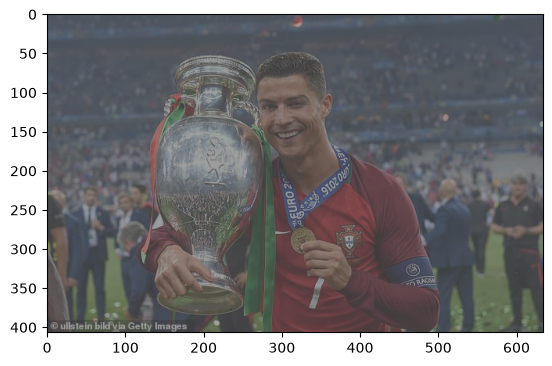

In [2]:
import math
import time
import numpy as np
import matplotlib.pyplot as plt

image = plt.imread('1.jpeg')
# the original already uses the full range [0, 255], so squeeze it to [60, 160] to see the stretch
image = (image * (100 / 255) + 60).astype(np.uint8)

plt.imshow(image)

h, w, d = image.shape

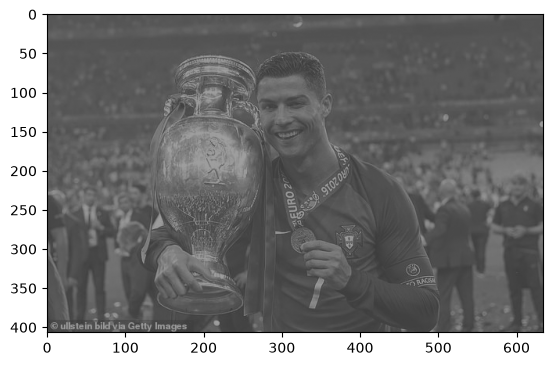

In [3]:
@cuda.jit
def grayscale(src, dst):
    tidx = cuda.threadIdx.x + cuda.blockIdx.x * cuda.blockDim.x
    tidy = cuda.threadIdx.y + cuda.blockIdx.y * cuda.blockDim.y
    if tidx >= src.shape[1] or tidy >= src.shape[0]:
        return
    dst[tidy, tidx] = np.uint8((src[tidy, tidx, 0] + src[tidy, tidx, 1] + src[tidy, tidx, 2]) / 3)

blockSize = (32, 32)
gridSize = (math.ceil(w / blockSize[0]), math.ceil(h / blockSize[1]))
devSrc = cuda.to_device(image)
devGray = cuda.device_array((h, w), np.uint8)
grayscale[gridSize, blockSize](devSrc, devGray)
gray = devGray.copy_to_host()
plt.imshow(gray, cmap='gray', vmin=0, vmax=255)

## Step 2: Find max/min (reduce with shared memory)

In [4]:
sharedSize = 256

@cuda.jit
def reduceMax(src, dst):
    cache = cuda.shared.array((sharedSize, ), np.uint8)
    localtid = cuda.threadIdx.x
    tid = cuda.threadIdx.x + cuda.blockIdx.x * cuda.blockDim.x
    if tid < src.shape[0]:
        cache[localtid] = src[tid]
    else:
        cache[localtid] = 0
    cuda.syncthreads()
    s = 1
    while s < cuda.blockDim.x:
        if localtid % (s * 2) == 0:
            cache[localtid] = max(cache[localtid], cache[localtid + s])
        cuda.syncthreads()
        s = s * 2
    if localtid == 0:
        dst[cuda.blockIdx.x] = cache[0]

@cuda.jit
def reduceMin(src, dst):
    cache = cuda.shared.array((sharedSize, ), np.uint8)
    localtid = cuda.threadIdx.x
    tid = cuda.threadIdx.x + cuda.blockIdx.x * cuda.blockDim.x
    if tid < src.shape[0]:
        cache[localtid] = src[tid]
    else:
        cache[localtid] = 255
    cuda.syncthreads()
    s = 1
    while s < cuda.blockDim.x:
        if localtid % (s * 2) == 0:
            cache[localtid] = min(cache[localtid], cache[localtid + s])
        cuda.syncthreads()
        s = s * 2
    if localtid == 0:
        dst[cuda.blockIdx.x] = cache[0]

# each block of 256 threads finds the max/min of its 256 pixels
devData = devGray.reshape(h * w)
gridReduce = math.ceil(h * w / sharedSize)
devMax = cuda.device_array(gridReduce, np.uint8)
devMin = cuda.device_array(gridReduce, np.uint8)
reduceMax[gridReduce, sharedSize](devData, devMax)
reduceMin[gridReduce, sharedSize](devData, devMin)

# only gridReduce values left (one per block), finish on the CPU
gmax = devMax.copy_to_host().max()
gmin = devMin.copy_to_host().min()

print(f"Blocks: {gridReduce}")
print(f"GPU max = {gmax}, min = {gmin}")
print(f"CPU max = {gray.max()}, min = {gray.min()}")

Blocks: 1008
GPU max = 160, min = 60
CPU max = 160, min = 60


## Step 3: Stretch (map)

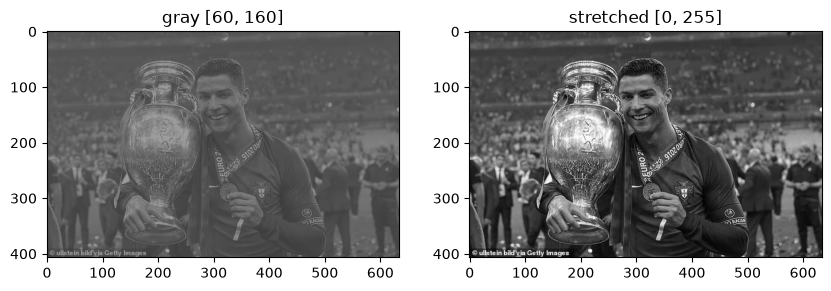

In [5]:
@cuda.jit
def stretch(src, dst, gmin, gmax):
    tidx = cuda.threadIdx.x + cuda.blockIdx.x * cuda.blockDim.x
    tidy = cuda.threadIdx.y + cuda.blockIdx.y * cuda.blockDim.y
    if tidx >= src.shape[1] or tidy >= src.shape[0]:
        return
    dst[tidy, tidx] = np.uint8((src[tidy, tidx] - gmin) / (gmax - gmin) * 255)

devStretch = cuda.device_array((h, w), np.uint8)
stretch[gridSize, blockSize](devGray, devStretch, np.float32(gmin), np.float32(gmax))
stretched = devStretch.copy_to_host()

plt.figure(figsize=(10, 4))
plt.subplot(1, 2, 1)
plt.imshow(gray, cmap='gray', vmin=0, vmax=255)
plt.title(f"gray [{gray.min()}, {gray.max()}]")
plt.subplot(1, 2, 2)
plt.imshow(stretched, cmap='gray', vmin=0, vmax=255)
plt.title(f"stretched [{stretched.min()}, {stretched.max()}]")
plt.show()

## Histogram before and after

In [ ]:
plt.figure(figsize=(8, 5))
plt.hist(gray.ravel(), bins=256, range=(0, 255), alpha=0.6, label='gray')
plt.hist(stretched.ravel(), bins=256, range=(0, 255), alpha=0.6, label='stretched')
plt.xlabel("Intensity")
plt.ylabel("Pixels")
plt.title("Histogram before and after stretch")
plt.legend()
plt.grid(True)
plt.show()

## Block size vs time

In [ ]:
block_sizes = [(4, 4), (8, 8), (16, 16), (32, 32)]
times_gray = []
times_stretch = []

for blockSize in block_sizes:
    gridSize = (math.ceil(w / blockSize[0]), math.ceil(h / blockSize[1]))

    start = time.time()
    grayscale[gridSize, blockSize](devSrc, devGray)
    cuda.synchronize()
    times_gray.append(time.time() - start)

    start = time.time()
    stretch[gridSize, blockSize](devGray, devStretch, np.float32(gmin), np.float32(gmax))
    cuda.synchronize()
    times_stretch.append(time.time() - start)

    print(f"Block size: {blockSize}")
    print(f"Grid size: {gridSize}")
    print(f"GPU time: {times_gray[-1]}, {times_stretch[-1]} seconds")

plt.figure(figsize=(8, 5))
plt.plot([str(b) for b in block_sizes], times_gray, marker='o', label='grayscale')
plt.plot([str(b) for b in block_sizes], times_stretch, marker='o', label='stretch')
plt.xlabel("2D Block Size")
plt.ylabel("Time (seconds)")
plt.title("CUDA 2D Block Size vs GPU Execution Time")
plt.legend()
plt.grid(True)
plt.show()

NameError: name 'math' is not defined

: 